# Readme

Plot responses by type.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import skeliner as sk

[Info] scikit-sparse not found. Falling back to scipy.sparse.linalg.spsolve.
[pywarper.surface] Optional dependency 'scikit-sparse' (CHOLMOD bindings) not found. Falling back to SciPy's sparse linear solver, which is ≈5–10× slower for large problems.

For platform-specific instructions see the project README:
	https://github.com/berenslab/pywarper#installation


In [2]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../data/preprocessed-data"
nuc_col_master='Updated Nuc ID (Sept 2)'
seg_col_master='Updated Seg ID (Sept 2)'

df_merged = data_loader.load_df_rois_morph(
    morph_folder="../../data/morphological-data",
    data_folder="../../data/preprocessed-data",
    nuc_col_master=nuc_col_master,
    seg_col_master=seg_col_master,
)

# Plot function

In [3]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):
    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

In [4]:
skel_dir = 'Y:/data/Eyewire2/morphologies-ew2/swc-final/2007c8b3d5870b8742b720823ceab1a0/9e713c5362f2535135fe15417bfec1fa'
swc_files = [f for f in os.listdir(skel_dir) if f.endswith('.npz')]
print(len(swc_files))

1631


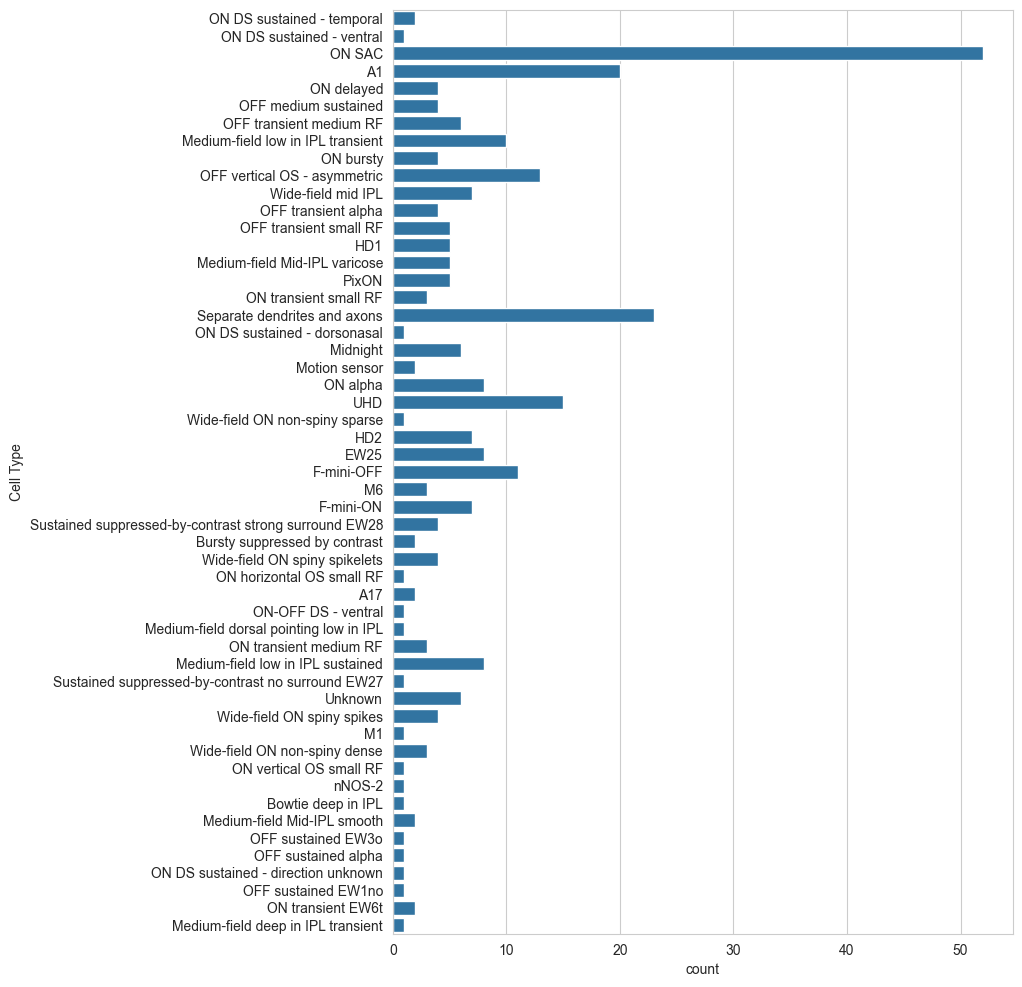

In [5]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

# Plot

In [6]:
fig_dir = './figures/'
os.makedirs(fig_dir, exist_ok=True)

In [7]:
t_chirp = np.arange(df_merged.chirp_average_norm.iloc[0].size) * df_merged.chirp_average_dt.iloc[0]
t_bar = np.arange(df_merged.bar_time_component.iloc[0].size) * df_merged.bar_snippets_dt.iloc[0]

In [8]:
from eyewire2_functional_analysis import plot

In [9]:
example_cell = {
    'nuc_id': "720575940563322189",
    'seg_id': "720575940559424389",
}

In [10]:
row = df_merged[df_merged['nuc_id'] == example_cell['nuc_id']]
skel = sk.io.load_npz(os.path.join(skel_dir, f"{example_cell['seg_id']}.npz"))

In [11]:
xmax, ymax, zmax = np.max(skel.nodes[skel.ntype == 3], axis=0)
xmin, ymin, zmin = np.min(skel.nodes[skel.ntype == 3], axis=0)

xlim = (xmin-10, xmax+30)
ylim = (ymin-10, ymax+10)
zlim = (zmin-10, zmax+5)

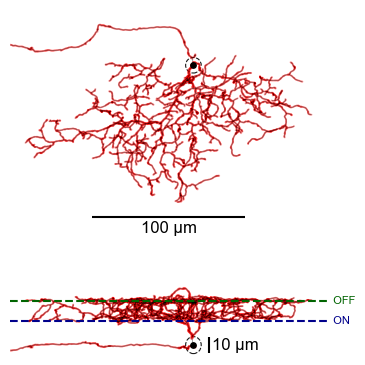

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(4, 5), height_ratios=(5, 1))

ax = axs[0]
sk.plot.projection(skel, ax=ax, xlim=ylim, ylim=xlim, plane='yx', draw_cylinders=False)
plot.plot_scale_bar(ax=ax, x0=np.mean(ylim), y0=xlim[0], size=100, text=True, unit='µm', tdist=2, fontsize=12)

ax = axs[1]
sk.plot.projection(skel, ax=ax, xlim=ylim, ylim=zlim, plane='yz')
ax.set_aspect('auto', 'box')
ax.plot(ylim, [0, 0], c='darkblue', ls='--', lw=1.5)
ax.text(ylim[1], 0, '  ON', va='center', ha='left', color='darkblue', fontsize=8)
ax.plot(ylim, [12, 12], c='darkgreen', ls='--', lw=1.5)
ax.text(ylim[1], 12, '  OFF', va='center', ha='left', color='darkgreen', fontsize=8)
plot.plot_scale_bar(ax=ax, x0=skel.soma.center[1]+ 10, y0=skel.soma.center[2], size=10, text=True, unit='µm', tdist=2, fontsize=12, orientation='v')

for ax in axs:
    ax.axis('off')

plt.savefig(os.path.join(fig_dir, 'fig4f.svg'))